                job_title    country experience_level education_level  year    salary  ai_risk_score primary_skill  skill_demand_score  job_openings job_survival_class salary_bucket ai_risk_category
0          Data Scientist        USA           Senior          Master  2022  61931.03           0.32        Python                  88         39158               Safe          High      Medium Risk
1       Software Engineer      India           Senior        Bachelor  2032  21330.84           0.52          Java                  80          7265      Medium Chance          High      Medium Risk
2          Data Scientist     Canada              Mid        Bachelor  2015  24211.17           0.25        Python                  70         22962      Medium Chance          High         Low Risk
3          Data Scientist      India            Entry             PhD  2034  11794.86           0.44        Python                  95         17023      Medium Chance        Medium      Medium Risk
4    

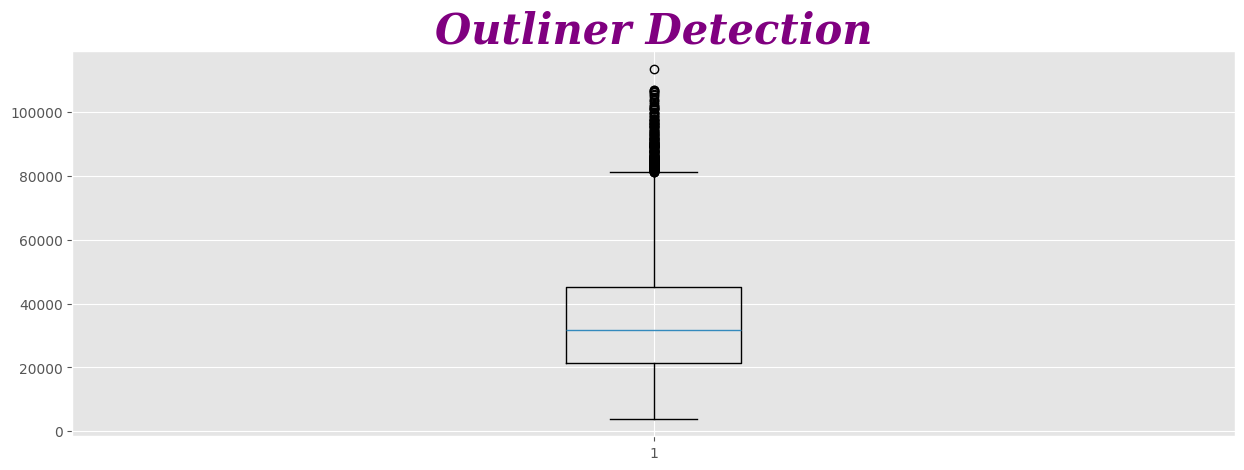

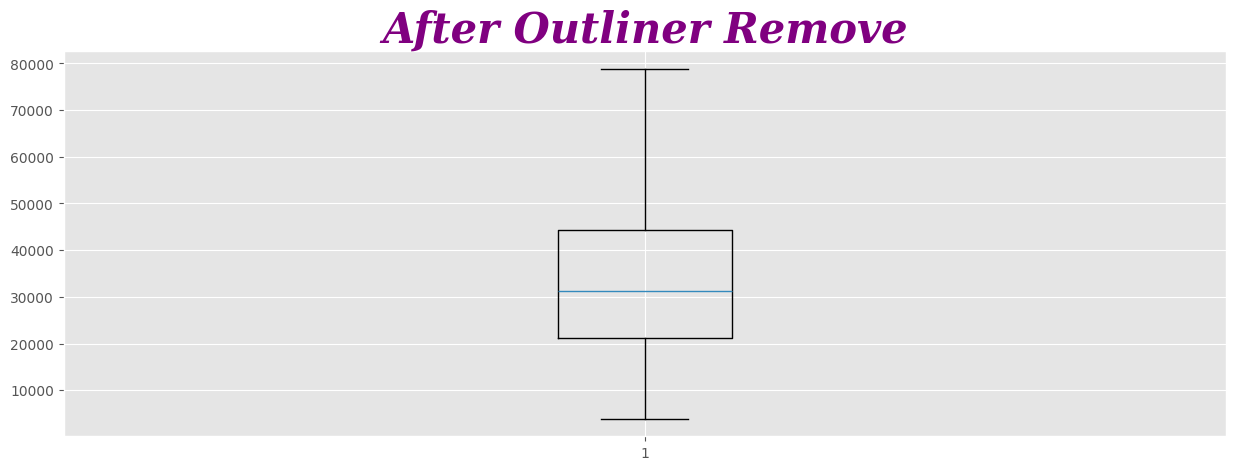

Number OF Rows & Columns ==  (12112, 13)
job_survival_class
Medium Chance    5806
Safe             4951
High Chance      1355
Name: count, dtype: int64


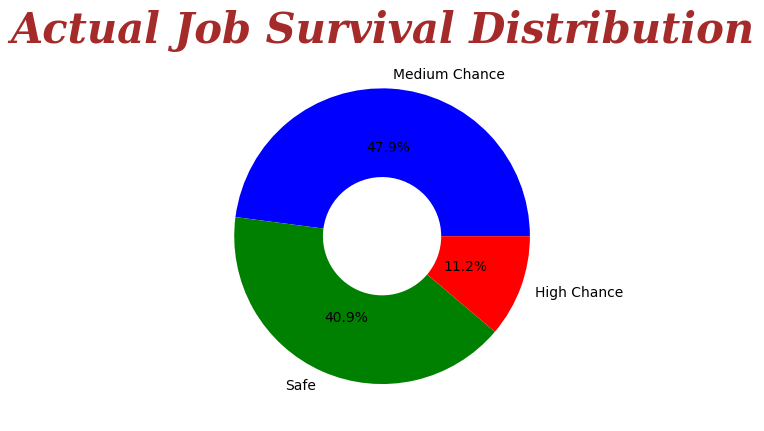

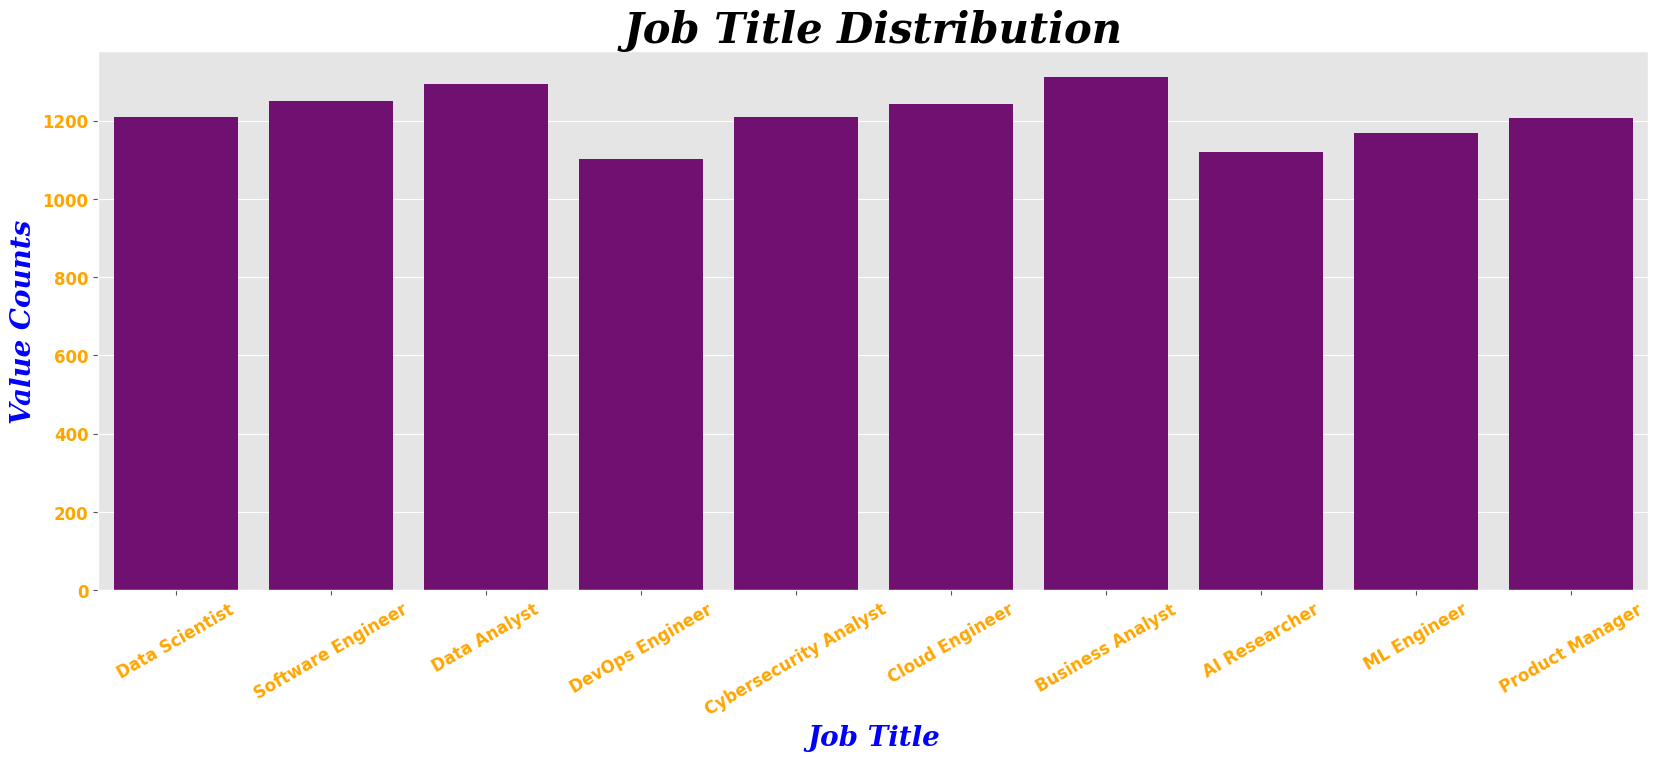

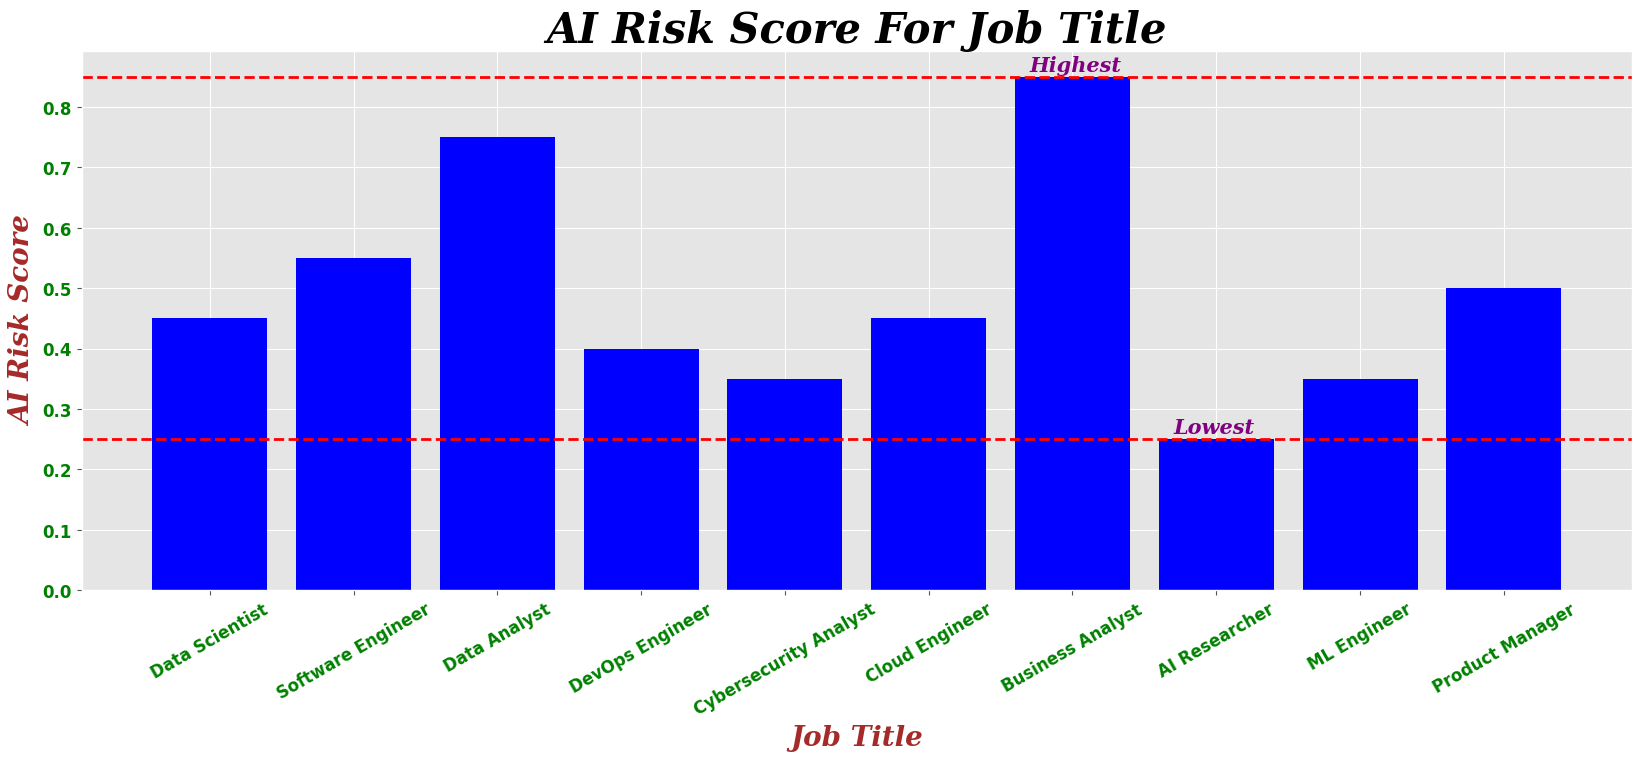

    job_title  country  experience_level  education_level  year    salary  ai_risk_score  primary_skill  skill_demand_score  job_openings job_survival_class salary_bucket  ai_risk_category
0           5        5                 2                1  2022  61931.03           0.32              5                  88         39158               Safe          High                 2
1           9        3                 2                0  2032  21330.84           0.52              4                  80          7265      Medium Chance          High                 2
2           5        1                 1                0  2015  24211.17           0.25              5                  70         22962      Medium Chance          High                 1
3           5        3                 0                2  2034  11794.86           0.44              5                  95         17023      Medium Chance        Medium                 2
4           4        1                 0               

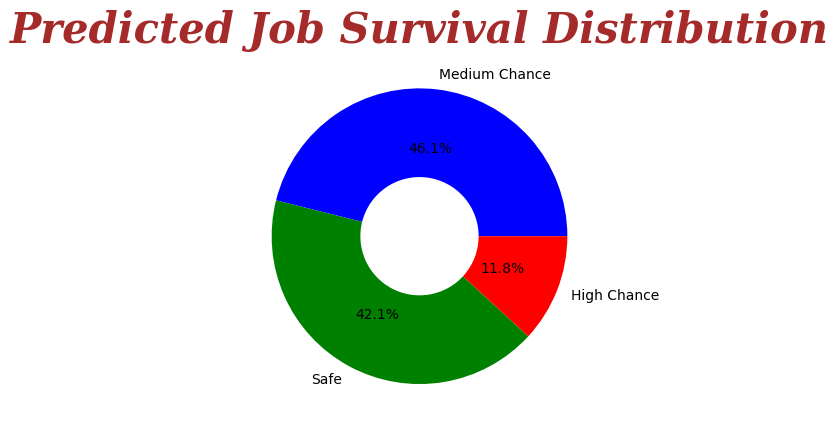

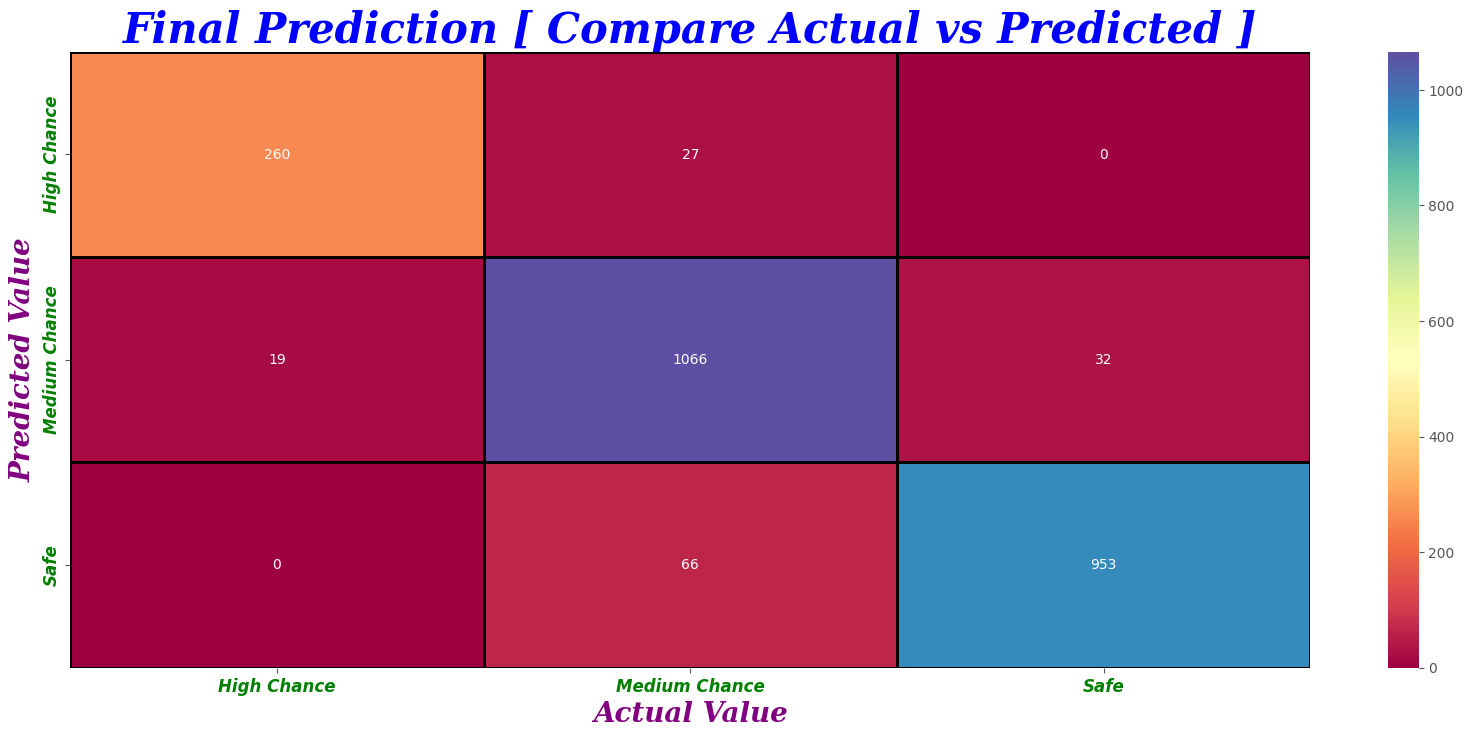

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use('ggplot')

pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
pd.set_option('display.width',None)
pd.set_option('display.expand_frame_repr',False)

JP=pd.read_csv("Future Of Jobs AI Dataset.csv")
print(JP.head(20))

print(JP.isna().sum())
# JP=JP[JP.duplicated()]
# print(JP)

plt.figure(figsize=(15,5))
plt.boxplot(JP['salary'])
plt.title("Outliner Detection",fontsize=30,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

Q1=JP['salary'].quantile(0.25)
Q3=JP['salary'].quantile(0.75)

IQR=Q3-Q1

lower=Q1 - 1.5 * IQR
upper=Q3 + 1.4 * IQR

JP=JP[ ( JP['salary'] > lower ) & ( JP['salary'] < upper )]

plt.figure(figsize=(15,5))
plt.boxplot(JP['salary'])
plt.title("After Outliner Remove",fontsize=30,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

print("Number OF Rows & Columns == ",JP.shape)

ABC=JP['job_survival_class'].value_counts()
print(ABC)

plt.pie(JP['job_survival_class'].value_counts(),labels=JP['job_survival_class'].value_counts().index,wedgeprops=dict(width=0.6),autopct='%1.1f%%',colors=['blue','green','red'])
plt.title("Actual Job Survival Distribution",fontsize=30,fontweight='bold',color='brown',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.figure(figsize=(20,7))
sns.countplot(x='job_title',data=JP,color='purple')
plt.title("Job Title Distribution",fontsize=30,color='black',fontweight='bold',fontdict={'family':'serif'},fontstyle='italic')
plt.xlabel("Job Title",fontweight='bold',color='blue',fontsize=20,fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("Value Counts",fontweight='bold',color='blue',fontsize=20,fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(rotation=30,fontweight='bold',color='orange',fontsize=12)
plt.yticks(fontweight='bold',color='orange',fontsize=12)
plt.show()

plt.figure(figsize=(20,7))
plt.bar(JP['job_title'],JP['ai_risk_score'],color='blue')
plt.xlabel("Job Title",fontsize=20,color='brown',fontweight='bold',fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("AI Risk Score",fontsize=20,color='brown',fontweight='bold',fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(rotation=30,color='green',fontweight='bold',fontsize=12)
plt.yticks(color='green',fontweight='bold',fontsize=12)
plt.title("AI Risk Score For Job Title",fontsize=30,fontweight='bold',color='black',fontdict={'family':'serif'},fontstyle='italic')
plt.axhline(y=0.85,linestyle='--',linewidth=2,color='red')
plt.text(5.70,0.86,"Highest",fontsize=15,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.axhline(y=0.25,linestyle='--',linewidth=2,color='red')
plt.text(6.70,0.26,"Lowest",fontsize=15,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

from sklearn.preprocessing import LabelEncoder

JP['job_title']=LabelEncoder().fit_transform(JP['job_title'])
JP['country']=LabelEncoder().fit_transform(JP['country'])
JP['experience_level']=LabelEncoder().fit_transform(JP['experience_level'])
JP['education_level']=LabelEncoder().fit_transform(JP['education_level'])
JP['primary_skill']=LabelEncoder().fit_transform(JP['primary_skill'])
JP['education_level']=LabelEncoder().fit_transform(JP['education_level'])
JP['ai_risk_category']=LabelEncoder().fit_transform(JP['ai_risk_category'])

print(JP.head(20))


x=JP[[
        'job_title','education_level','salary',
        'ai_risk_score','primary_skill','skill_demand_score','job_openings','ai_risk_category'
     ]]

y=JP['job_survival_class']


from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=67)

score=cross_val_score(model,x,y,cv=5,scoring='accuracy')

print("\n")
print("CVS === ",score)
print("Average Of CVS === ",score.mean())


from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


# from sklearn.tree import DecisionTreeClassifier

# model=DecisionTreeClassifier(max_depth=5,random_state=89)

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


from sklearn.ensemble import RandomForestClassifier

model=RandomForestClassifier(n_estimators=100,max_depth=10,random_state=99)

model.fit(x_train,y_train)
Y_Pred=model.predict(x_test)


# from sklearn.neighbors import KNeighborsClassifier

# model=KNeighborsClassifier(n_neighbors=5,weights='uniform')

# model.fit(x_train,y_train)
# Y_Pred=model.predict(x_test)


Train=model.score(x_train,y_train)
Test=model.score(x_test,y_test)

print("\n")
print("Train Score == ",Train)
print("Test SCore ==",Test)

from sklearn.metrics import accuracy_score , classification_report  , confusion_matrix

print("\n")
print("Accuracy Score :")
print(accuracy_score(y_test,Y_Pred) * 100 , "%")

print("\n")
print("Confusion Matrix :")
CM=confusion_matrix(y_test,Y_Pred)
print(CM)

print("\n")
print("Classification Report :")
print(classification_report(y_test,Y_Pred))


plt.pie(y_test.value_counts(),labels=y_test.value_counts().index,wedgeprops=dict(width=0.6),autopct='%1.1f%%',colors=['blue','green','red'])
plt.title("Predicted Job Survival Distribution",fontsize=30,fontweight='bold',color='brown',fontdict={'family':'serif'},fontstyle='italic')
plt.show()

plt.figure(figsize=(20,8))
sns.heatmap(CM,annot=True,fmt='d',cmap='Spectral',xticklabels=['High Chance','Medium Chance','Safe'],yticklabels=['High Chance','Medium Chance','Safe'],linewidths=2,linecolor='black')
plt.title("Final Prediction [ Compare Actual vs Predicted ]",fontsize=30,fontweight='bold',color='blue',fontdict={'family':'serif'},fontstyle='italic')
plt.xlabel("Actual Value",fontsize=20,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.ylabel("Predicted Value",fontsize=20,fontweight='bold',color='purple',fontdict={'family':'serif'},fontstyle='italic')
plt.xticks(fontweight='bold',color='green',fontsize=12,fontstyle='italic')
plt.yticks(fontweight='bold',color='green',fontsize=12,fontstyle='italic')
plt.show()